In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

from scripts.material_aware_training import material_aware_training
from scripts.config import PathConfig, MaterialAwareTrainingConfig
from flare.dataset import DatasetLoader
from scripts.flare_inference import build_flare_pipeline, run_inference, visualize_image_batch, visualize_image_buffers,evaluate

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


/home/jsickert/miniconda3/envs/flare/lib/python3.9/site-packages/torch/utils/cpp_extension.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging  # type: ignore[attr-defined]


In [2]:
import math

class NoDecay:
    def __init__(self, name):
        self.name = name

    def __call__(self, loss_weights, iteration, total_iterations, args: MaterialAwareTrainingConfig):
        pass

class StepDecay:
    def __init__(self, decay_iterations: list[int], decay: float, name):
        self.name = name
        self.decay_iterations = decay_iterations
        self.decay = decay

    def __call__(self, loss_weights, iteration, total_iterations, args: MaterialAwareTrainingConfig):
        if iteration in self.decay_iterations:
            loss_weights["diffusion_normal"] *= self.decay
            loss_weights["diffusion_albedo"] *= self.decay
            loss_weights["diffusion_roughness"] *= self.decay
            loss_weights["diffusion_irradiance"] *= self.decay


class LinearDecay:
    def __init__(self, name):
        self.name = name

    def __call__(self, loss_weights, iteration, total_iterations, args: MaterialAwareTrainingConfig):

        progress = iteration / total_iterations
        loss_weights["diffusion_normal"] = args.weight_diffusion_normal_regularization * max(0, (1 - progress))
        loss_weights["diffusion_albedo"] *= args.weight_diffusion_albedo_regularization * max(0, (1 - progress))
        loss_weights["diffusion_roughness"] *= args.weight_diffusion_roughness_regularization * max(0, (1 - progress))
        loss_weights["diffusion_irradiance"] *= args.weight_diffusion_irradiance_regularization * max(0, (1 - progress))


class CosineDecay:
    def __init__(self, name):
        self.name = name

    def __call__(self, loss_weights, iteration, total_iterations, args: MaterialAwareTrainingConfig):

        progress = min(iteration / total_iterations, 1.0)
        loss_weights["diffusion_normal"] = args.weight_diffusion_normal_regularization * 0.5 * (1 + math.cos(math.pi * progress))
        loss_weights["diffusion_albedo"] *= args.weight_diffusion_albedo_regularization * 0.5 * (1 + math.cos(math.pi * progress))
        loss_weights["diffusion_roughness"] *= args.weight_diffusion_roughness_regularization * 0.5 * (1 + math.cos(math.pi * progress))
        loss_weights["diffusion_irradiance"] *= args.weight_diffusion_irradiance_regularization * 0.5 * (1 + math.cos(math.pi * progress))

In [3]:
working_dir = "/home/jsickert/adl4cv"
run_name = "test"
input_dir = "DATA/001"
train_dir = ["MVI_1814", "MVI_1810"]
output_dir = "experiment_decay_rgbx"
flame_path = "/home/jsickert/adl4cv/adl4cv_ws25-26_Relightable-Avatars/flare/flame/FLAME2020/generic_model.pkl"
diffusion_dir = Path("/home/jsickert/adl4cv/flare_diffusion_channels/rgbx/001")
ghostbone = True
batch_size = 2
eval_dir = ["MVI_1812"]

path_config = PathConfig(
        _working_dir=working_dir,
        run_name=run_name,
        input_dir=input_dir,
        output_dir=output_dir,
        flame_path=flame_path,
        diffusion_dir=diffusion_dir,
        train_dir=train_dir,
        eval_dir=eval_dir,
    )

In [4]:
dataset_train = DatasetLoader(path_config, train_dir=path_config.train_dir, sample_ratio=1, pre_load=True)
dataset_val = DatasetLoader(path_config, train_dir=path_config.eval_dir, sample_ratio=1, pre_load=False)

dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=2, collate_fn=dataset_train.collate, shuffle=True, drop_last=True)
dataloader_val = torch.utils.data.DataLoader(dataset_val, batch_size=4, collate_fn=dataset_val.collate, shuffle=True, drop_last=True)

loaded 2903 views


In [ ]:
decay_schedules = [
    NoDecay(name="no_decay"),
    # StepDecay(decay_iterations=[100], decay=0.5, name="step_decay_early"), # early decay
    # StepDecay(decay_iterations=[500, 1000, 1500, 2000, 2500], decay=0.8, name="step_decay_500"), # step wise decay
    # StepDecay(decay_iterations=[1000, 2000], decay=0.5, name="step_decay_late"), # late decay
    # LinearDecay(name="linear_decay"),
    # CosineDecay(name="cosine_decay"),
]

In [5]:
path_config.run_name = "no_decay_both_stages"

evaluate(
    path_config=path_config,
    dataset_val=dataset_val,
    dataloader_val=dataloader_val,
)

creating the FLAME Decoder
STAGE 2: Using hashgrid (tinycudann) for intrinsic materials
{'material_mlp_ch': 5, 'light_mlp_ch': 3, 'material_mlp_dims': [64, 64], 'light_mlp_dims': [64, 64]}


Using /home/jsickert/.cache/torch_extensions/py39_cu116 as PyTorch extensions root...
Detected CUDA files, patching ldflags
Emitting ninja build file /home/jsickert/.cache/torch_extensions/py39_cu116/renderutils_plugin/build.ninja...
Building extension module renderutils_plugin...
Allowing ninja to set a default number of workers... (overridable by setting the environment variable MAX_JOBS=N)


ninja: no work to do.


Loading extension module renderutils_plugin...


rgb
image index start from:  1
['1791', '1473', '499', '543', '115', '1686', '710', '167', '310', '1482', '1467', '882', '1364', '904', '735', '885', '1560', '211', '1714', '1172', '156', '89', '1134', '588', '104', '1080', '894', '1752', '1269', '1083', '1630', '1672', '675', '1487', '1405', '739', '871', '294', '627', '733', '1014', '23', '1521', '434', '317', '1579', '1812', '1675', '1444', '173', '1137', '1709', '1626', '707', '10', '624', '1210', '446', '1085', '1428', '1734', '886', '1494', '1347', '1737', '1776', '1251', '1326', '1437', '1522', '1407', '1304', '1638', '231', '965', '1076', '1021', '19', '487', '21', '1561', '972', '838', '1742', '1383', '616', '509', '309', '1376', '683', '681', '137', '797', '1271', '1392', '336', '577', '836', '1597', '768', '1352', '117', '1550', '523', '464', '605', '498', '568', '99', '48', '907', '1357', '1485', '1689', '940', '360', '948', '43', '1537', '859', '302', '1566', '1287', '942', '1516', '705', '562', '1222', '1731', '79', '827'

...

 99%|█████████▉| 1801/1820 [03:08<00:02,  9.37it/s]

0.026586444107815622	0.09945494079341491	0.855593069659339	24.017637924618192	nan


100%|██████████| 1820/1820 [03:10<00:00,  9.55it/s]

Written result to  /home/jsickert/adl4cv/experiment_decay_rgbx/no_decay_both_stages/images_evaluation/results_no_cloth_rgb.npz
0.026579633455436964	0.09942491047166206	0.8556107466364955	24.020117398146745


(0.026579633455436964,
 0.09942491047166206,
 0.8556107466364955,
 24.020117398146745)

In [11]:
for decay_schedule in decay_schedules:
    path_config.run_name = decay_schedule.name + "_only_stage_1"
    training_config1 = MaterialAwareTrainingConfig.default_stage_1_config(batch_size=batch_size, ghostbone=ghostbone)
    training_config2 = MaterialAwareTrainingConfig.default_stage_2_config(batch_size=batch_size, ghostbone=ghostbone)

    training_config2.weight_diffusion_albedo_regularization = 0.0
    training_config2.weight_diffusion_normal_regularization = 0.0
    training_config2.weight_diffusion_roughness_regularization = 0.0

    material_aware_training(
        path_config=path_config,
        args1=training_config1,
        args2=training_config2,
        dataset_train=dataset_train,
        dataloader_train=dataloader_train,
        diff_reg_decay_schedule=None
    )

    evaluate(
        path_config=path_config,
        dataset_val=dataset_val,
        dataloader_val=dataloader_val,
    )


for decay_schedule in decay_schedules:
    path_config = PathConfig(
        _working_dir=working_dir,
        run_name=decay_schedule.name + "_both_stages",
        input_dir=input_dir,
        output_dir=output_dir,
        flame_path=flame_path,
        diffusion_dir=diffusion_dir,
        train_dir=train_dir,
        eval_dir=eval_dir,
    )

    training_config1 = MaterialAwareTrainingConfig.default_stage_1_config(batch_size=batch_size, ghostbone=ghostbone)
    training_config2 = MaterialAwareTrainingConfig.default_stage_2_config(batch_size=batch_size, ghostbone=ghostbone)

    material_aware_training(
        path_config=path_config,
        args1=training_config1,
        args2=training_config2,
        dataset_train=dataset_train,
        dataloader_train=dataloader_train,
        diff_reg_decay_schedule=decay_schedule
    )

    evaluate(
        path_config=path_config,
        dataset_val=dataset_val,
        dataloader_val=dataloader_val,
    )

creating the FLAME Decoder
Rasterizing: ['mask', 'position', 'normal', 'canonical_position']
Training Deformer
STAGE 1: Using positional encoding (NeRF) for intrinsic materials
{'material_mlp_ch': 5, 'light_mlp_ch': 3, 'material_mlp_dims': [128, 128, 128, 128], 'light_mlp_dims': [64, 64]}
{'mask': 2.0, 'normal': 0.1, 'laplacian': 60.0, 'shading': 1.0, 'perceptual_loss': 0.1, 'albedo_regularization': 0.01, 'roughness_regularization': 0.01, 'white_light_regularization': 0.01, 'fresnel_coeff': 0.01, 'diffusion_normal': 0.01, 'diffusion_albedo': 0.01, 'diffusion_roughness': 0.01, 'diffusion_irradiance': 0.0, 'flame_regularization': 1.0}
Batch Size: 2
Iterations: 2902


Epoch 0, Iter 1:   0%|          | 0/2 [00:00<?, ?it/s]Using /home/jsickert/.cache/torch_extensions/py39_cu116 as PyTorch extensions root...
Detected CUDA files, patching ldflags
Emitting ninja build file /home/jsickert/.cache/torch_extensions/py39_cu116/renderutils_plugin/build.ninja...
Building extension module renderutils_plugin...
Allowing ninja to set a default number of workers... (overridable by setting the environment variable MAX_JOBS=N)


ninja: no work to do.


Loading extension module renderutils_plugin...
Epoch 0, Iter 100:   0%|          | 0/2 [00:40<?, ?it/s, loss=0.388]

Decaying flame regularization


...

Epoch 1, Iter 2902: 100%|██████████| 2/2 [14:37<00:00, 438.66s/it, loss=0.0727]


TIME TAKEN (mins): 14
loading mesh from: /home/jsickert/adl4cv/experiment_decay_rgbx/no_decay_both_stages/stage_1/meshes/mesh_latest.obj
Rasterizing: ['mask', 'position', 'normal', 'canonical_position']
Loading deformer network trained in the previous stage
STAGE 2: Using hashgrid (tinycudann) for intrinsic materials
{'material_mlp_ch': 5, 'light_mlp_ch': 3, 'material_mlp_dims': [64, 64], 'light_mlp_dims': [64, 64]}
{'mask': 2.0, 'normal': 0.1, 'laplacian': 60.0, 'shading': 1.0, 'perceptual_loss': 0.1, 'albedo_regularization': 0.01, 'roughness_regularization': 0.01, 'white_light_regularization': 0.01, 'fresnel_coeff': 0.01, 'diffusion_normal': 0.01, 'diffusion_albedo': 0.01, 'diffusion_roughness': 0.01, 'diffusion_irradiance': 0.0, 'flame_regularization': 0.0}
Batch Size: 2
Iterations: 1451


Epoch 0, Iter 1451: 100%|██████████| 1/1 [06:50<00:00, 410.51s/it, loss=0.0711]


TIME TAKEN (mins): 6
creating the FLAME Decoder
STAGE 2: Using hashgrid (tinycudann) for intrinsic materials
{'material_mlp_ch': 5, 'light_mlp_ch': 3, 'material_mlp_dims': [64, 64], 'light_mlp_dims': [64, 64]}


RuntimeError: CUDA error: an illegal memory access was encountered
CUDA kernel errors might be asynchronously reported at some other API call,so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1.

In [ ]:
baseline_metrics = np.load("/home/jsickert/adl4cv/MODELS/001/images_evaluation/qualitative_results/results_no_cloth_rgb.npz")

BASELINE_RESULTS = {
    "MAE": baseline_metrics["mae_l"].mean(),
    "PSNR": baseline_metrics["psnr_l"].mean(),
    "SSIM": baseline_metrics["ssim_l"].mean(),
    "LPIPS": baseline_metrics["perceptual_l"],
}

BASELINE_RESULTS

{'MAE': 0.0266, 'PSNR': 23.8811, 'SSIM': 0.8581, 'LPIPS': 0.098}

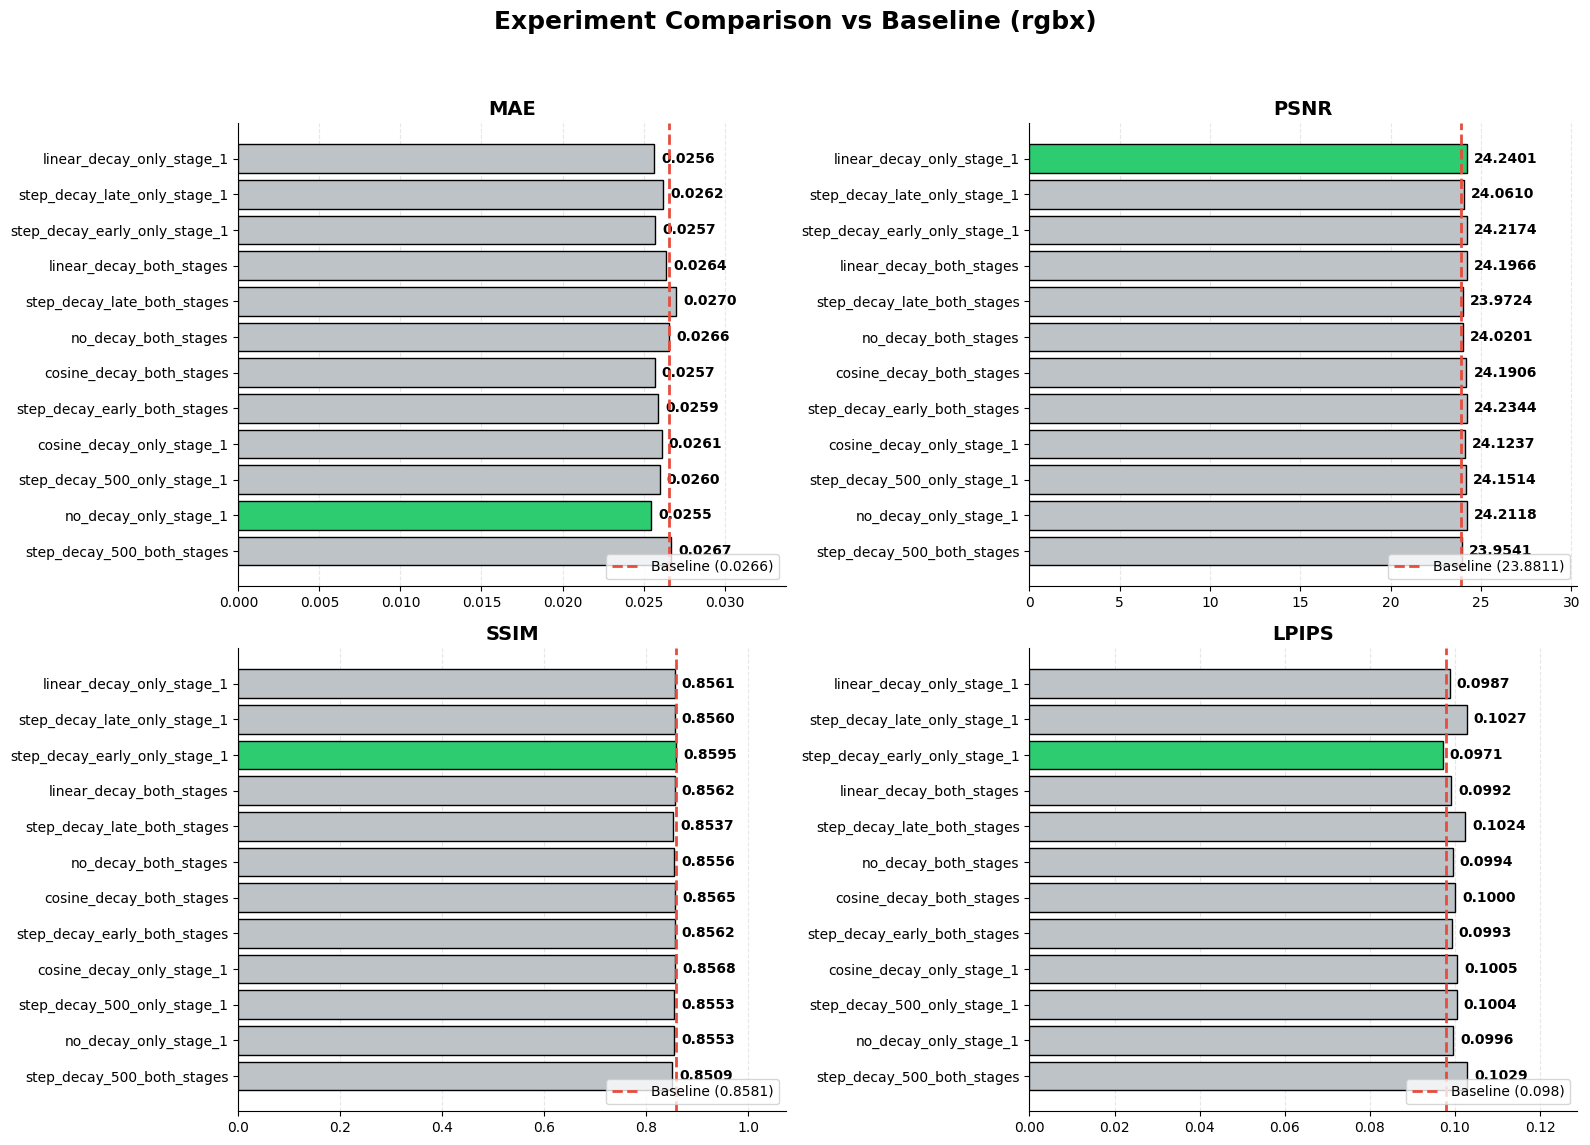

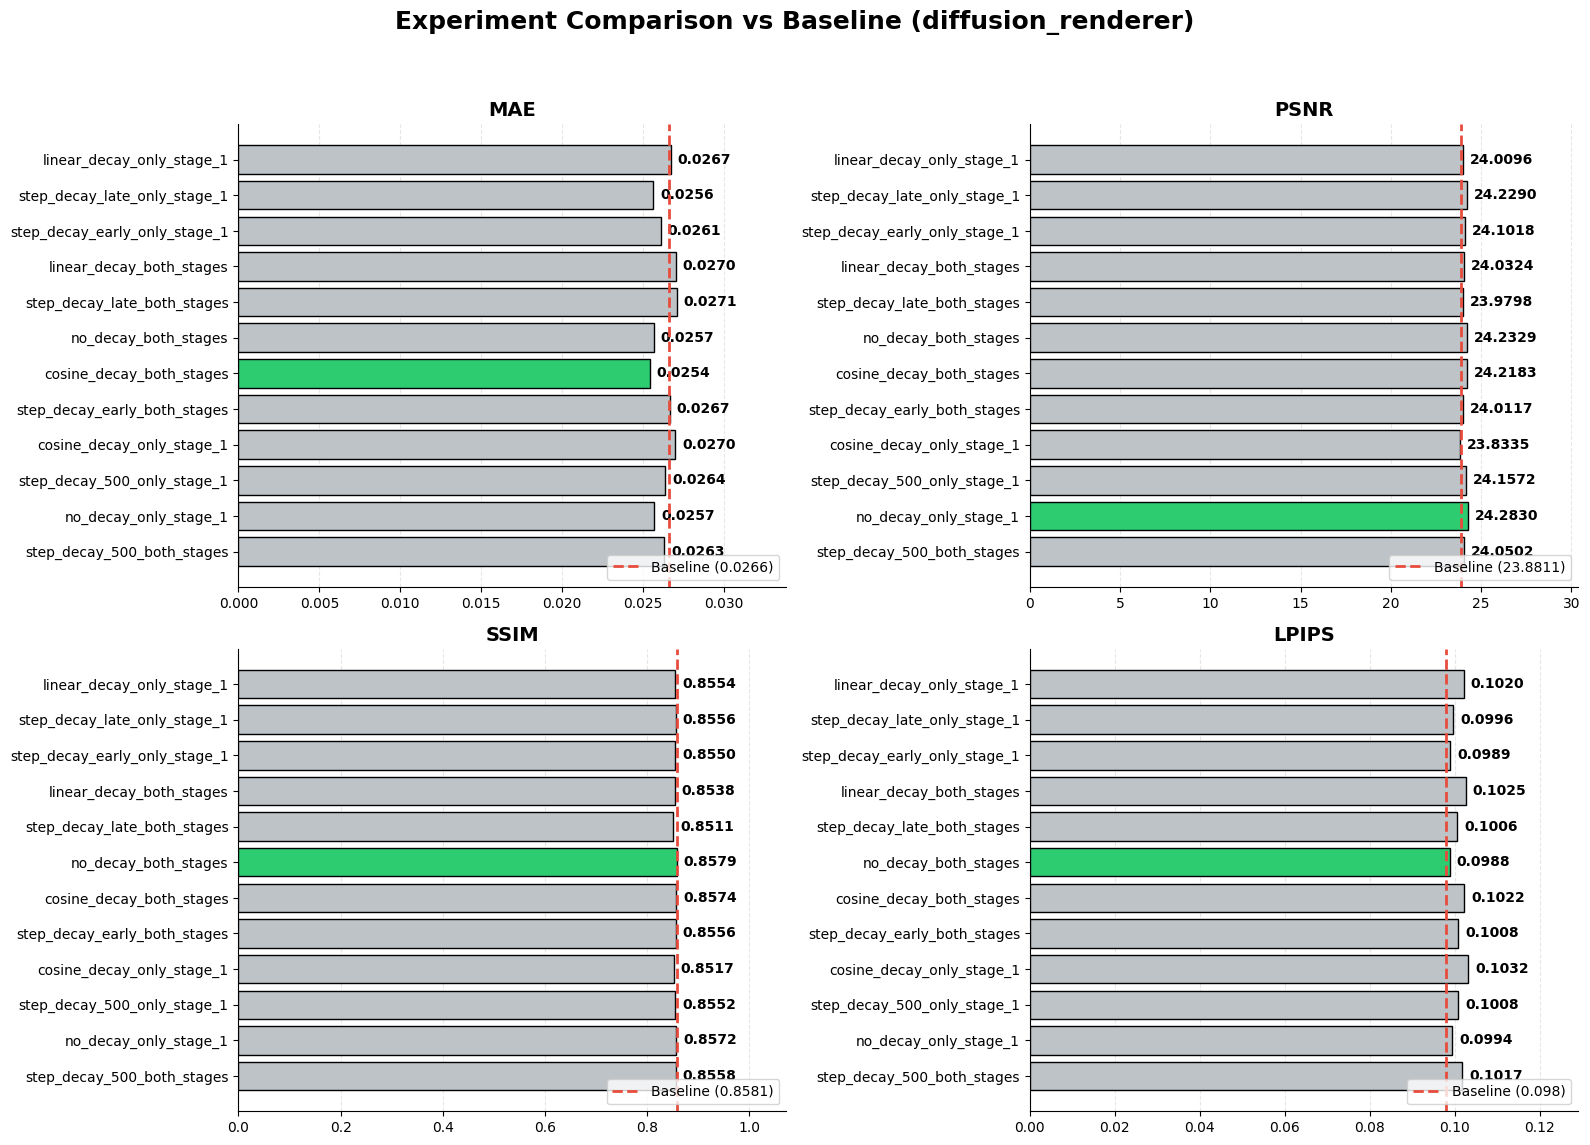

In [ ]:
for diffusion_model in ["rgbx", "diffusion_renderer"]:

    experiment_names = []
    results = {"MAE": [], "PSNR": [], "SSIM": [], "LPIPS": []}

    for experiment in Path(f"/home/jsickert/adl4cv/experiment_decay_{diffusion_model}").iterdir():
        metrics = np.load(experiment / "images_evaluation" / "results_no_cloth_rgb.npz")
        results["MAE"].append(metrics["mae_l"].mean() - )
        results["PSNR"].append(metrics["psnr_l"].mean())
        results["SSIM"].append(metrics["ssim_l"].mean())
        results["LPIPS"].append(metrics["perceptual_l"].mean())
        experiment_names.append(experiment.name)


    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    for i, (metric_name, values) in enumerate(results.items()):
        values = np.array(values)
        baseline_val = BASELINE_RESULTS[metric_name]

        if metric_name in ["PSNR", "SSIM"]:
            winner_idx = np.argmax(values)
        else:
            winner_idx = np.argmin(values)
        
        colors = ['#2ecc71' if j == winner_idx else '#bdc3c7' for j in range(len(values))]
        
        bars = axes[i].barh(experiment_names, values, color=colors, edgecolor='black', zorder=3)
        
        axes[i].axvline(baseline_val, color='#e74c3c', linestyle='--', linewidth=2, label=f'Baseline ({baseline_val})', zorder=4)
        
        axes[i].bar_label(bars, fmt='%.4f', padding=5, fontweight='bold')
        
        axes[i].set_title(f"{metric_name}", fontweight='bold', fontsize=14)
        axes[i].invert_yaxis()
        axes[i].spines['right'].set_visible(False)
        axes[i].spines['top'].set_visible(False)
        axes[i].grid(axis='x', linestyle='--', alpha=0.3, zorder=0)
        axes[i].legend(loc='lower right')
        
        max_val = max(max(values), baseline_val)
        axes[i].set_xlim(0, max_val * 1.25)

    plt.suptitle(f"Experiment Comparison vs Baseline ({diffusion_model})", fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [59]:
baseline_metrics = np.load("/home/jsickert/adl4cv/MODELS/001/images_evaluation/qualitative_results/results_no_cloth_rgb.npz", allow_pickle=True)
baseline_metrics = pd.DataFrame({key: baseline_metrics[key] for key in baseline_metrics.files})
baseline_metrics = baseline_metrics[["subfolders", "filenames", "mae_l", "perceptual_l", "ssim_l", "psnr_l"]]

linear_decay_stage_1_metrics = np.load("/home/jsickert/adl4cv/experiment_decay/linear_decay_only_stage_1/images_evaluation/results_no_cloth_rgb.npz")
linear_decay_stage_1_metrics = pd.DataFrame({key: linear_decay_stage_1_metrics[key] for key in linear_decay_stage_1_metrics.files})
linear_decay_stage_1_metrics = linear_decay_stage_1_metrics[["subfolders", "filenames", "mae_l", "perceptual_l", "ssim_l", "psnr_l"]]